# Context

This notebook is a continuation of the previous notebook, "NFL Offensive Tendencies Clustering: 2025". That notebook used NFL play-by-play and formation data from the 2025 regular season to create 10 distinct play archetypes, which were then used to group all 32 teams into 8 offensive tendency groupings.

This notebook aims to apply those models, without retraining, to data from the 2023 and 2024 regular season, to ask two follow-up questions:

1. Do certain offensive philosophies consistenly lead to more wins?
2. How does a team's success change when using different offensive philosophies?

Methodology explanation: there will be no retraining on season-specific data, because we are attempting to examine how different 2025 groupings performed over previous seasons. 3 years is a reasonable time frame which the league as a whole has not changed so much that this assumption is far-fetched.

In [25]:
!pip install nflreadpy

In [26]:
import joblib
import nflreadpy as nfl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [27]:
final_kmeans = joblib.load("nfl_offensive_kmeans_model_v2.joblib")
scaler_coaches = joblib.load("scaler_coaches_v2.joblib")
coaches_kmeans = joblib.load("kmeans_coaches_philisophy_v2.joblib")

In [28]:
seasons = list(range(2023, 2026))

season_data = nfl.load_schedules(seasons)
season_data = season_data.to_pandas()

season_data = season_data[(season_data["game_type"] == "REG")]

melted = season_data.melt(
    id_vars = ["result", "season"],
    value_vars = ["home_team", "away_team"],
    var_name = "home_away",
    value_name = "team"
)

melted["W"] = ((melted["home_away"] == "home_team") & (melted["result"] > 0)) | ((melted["home_away"] == "away_team") & (melted["result"] < 0))
melted["L"] = ((melted["home_away"] == "home_team") & (melted["result"] < 0)) | ((melted["home_away"] == "away_team") & (melted["result"] > 0))
melted["T"] = melted["result"] == 0

standings = (
    melted.groupby(["season", "team"])[["W", "L", "T"]]
    .sum()
    .astype(int)
    .reset_index()
)

standings = standings.sort_values(by = ["season", "W"], ascending = [True, False])

In [29]:
cols_from_pbp_continuous = [
    "yardline_100", "half_seconds_remaining", "game_seconds_remaining", "ydstogo",
    "goal_to_go", "fg_prob", "td_prob", "wp", "ep", "xpass"
]

cols_from_pbp_categorical = [
    "game_half", "down","qtr", "drive", "series", "posteam_timeouts_remaining",
    "defteam_timeouts_remaining", "play_type", "shotgun", "no_huddle", "qb_dropback", "qb_scramble",
    "pass_length", "pass_location", "run_location", "run_gap", "timeout"
]

def count_positions(positions_string):
  position_list = positions_string.strip().upper().split(";")
  return dict(Counter(position_list))

def get_count(pos_dict, position_key):
  if isinstance(pos_dict, dict):
    return pos_dict.get(position_key, 0)
  else:
    return 0

cols_from_participation = [
    "nflverse_game_id", "play_id", "possession_team", "defense_positions", "defenders_in_box", "number_of_pass_rushers",
    "defense_coverage_type", "offense_positions", "offense_formation"
]


# Normalization

The trained play archetype model and coach philosophy model are loaded directly and applied without retraining. However, a new scaler is fit on each season's team profiles before predicting philosophy groups.

This is intentional. Using the original 2025 scaler on earlier seasons caused league-wide shifts in offensive tendency, such as the gradual increase in pass rate across the league, to dominate the scaling, resulting in all teams being assigned to the same group. Re-scaling within each season neutralizes those macro trends and allows the clustering to capture relative differences between teams within that year.

In [30]:
all_tendencies = []

for year in seasons:

  pbp = nfl.load_pbp([year])
  participation = nfl.load_participation([year])
  pbp = pbp.to_pandas()
  participation = participation.to_pandas()

  pbp = pbp[
        (pbp["special_teams_play"] == 0) &
        (pbp["play_type"].isin(["pass", "run"])) &
        (pbp["qb_kneel"] == 0) &
        (pbp["qb_spike"] == 0) &
        (pbp["posteam"].notna()) &
        (pbp["down"].notna())
    ]

  position_counts = participation[["nflverse_game_id", "play_id", "defense_positions", "offense_positions"]].copy()

  position_counts["defense_positions"] = position_counts["defense_positions"].apply(count_positions)
  position_counts["offense_positions"] = position_counts["offense_positions"].apply(count_positions)

  offensive_position_columns = pd.DataFrame.from_records(position_counts["offense_positions"].fillna({}))
  offensive_position_columns = offensive_position_columns.fillna(0).astype(int)
  offensive_position_columns.columns = [f"n_off_{c.lower()}" for c in offensive_position_columns.columns]

  defensive_position_columns = pd.DataFrame.from_records(position_counts["defense_positions"].fillna({}))
  defensive_position_columns = defensive_position_columns.fillna(0).astype(int)
  defensive_position_columns.columns = [f"n_def_{c.lower()}" for c in defensive_position_columns.columns]

  position_counts = pd.concat([position_counts, offensive_position_columns, defensive_position_columns], axis = 1)
  position_counts = position_counts.drop(columns = ["defense_positions", "offense_positions"])

  participation = participation[cols_from_participation]
  participation = participation.merge(position_counts, on = ["nflverse_game_id", "play_id"])
  participation = participation.drop(columns = ["offense_positions", "defense_positions"])
  participation = participation.rename(columns = {"nflverse_game_id": "game_id"})


  pbp_categorical = pbp[cols_from_pbp_categorical + ["game_id", "play_id", "posteam_score", "defteam_score", "posteam"]].copy()
  pbp_continuous = pbp[cols_from_pbp_continuous + ["game_id", "play_id"]]

  pbp_categorical["posteam_score"] = pd.to_numeric(pbp_categorical["posteam_score"], errors = "coerce").fillna(0)
  pbp_categorical["defteam_score"] = pd.to_numeric(pbp_categorical["defteam_score"], errors = "coerce").fillna(0)
  pbp_categorical["score_diff"] = pbp_categorical["posteam_score"] - pbp_categorical["defteam_score"]
  pbp_categorical = pbp_categorical.drop(columns = ["posteam_score", "defteam_score"])

  master = pbp_continuous.merge(pbp_categorical, on = ["game_id", "play_id"])
  master = master.merge(participation, on = ["game_id", "play_id"])

  scaler = StandardScaler()

  X_scaled = scaler.fit_transform(master[cols_from_pbp_continuous].fillna(0))
  scaled_data = pd.DataFrame(X_scaled, columns = cols_from_pbp_continuous, index = master.index)

  all_categorical = list(set(cols_from_pbp_categorical + participation.columns.tolist()))

  ignore_cols = ["game_id", "play_id", "posteam"]
  all_categorical = [c for c in all_categorical if c not in ignore_cols]

  num_cats = master[all_categorical].select_dtypes(include='number').columns
  master[num_cats] = master[num_cats].fillna(0.0).astype(float)

  str_cats = [c for c in all_categorical if c not in num_cats]
  for col in str_cats:
    master[col] = master[col].fillna("UNKNOWN").astype(str).replace({"None": "UNKNOWN", "nan": "UNKNOWN"})

  binary_data = pd.get_dummies(master[all_categorical].astype(str), dtype = int)

  scaled_data = pd.DataFrame(
      scaled_data.values if hasattr(scaled_data, "values") else scaled_data,
      columns = scaled_data.columns if hasattr(scaled_data, "columns") else cols_from_pbp_continuous,
      index = master.index
  )

  x_final = pd.concat([scaled_data, binary_data], axis = 1)
  x_final = x_final.reindex(columns = final_kmeans.feature_names_in_, fill_value = 0)
  master["play_archetype"] = final_kmeans.predict(x_final)

  team_profiles = pd.crosstab(
      master["posteam"],
      master["play_archetype"],
      normalize = "index"
  )

  all_archetypes = list(range(final_kmeans.n_clusters))
  team_profiles = team_profiles.reindex(columns = all_archetypes, fill_value = 0)

  temp_scaler_for_coaches = StandardScaler()
  scaled_profiles = temp_scaler_for_coaches.fit_transform(team_profiles)
  team_profiles["offensive_tendency_group"] = coaches_kmeans.predict(scaled_profiles)

  year_tendencies = team_profiles[["offensive_tendency_group"]].reset_index()
  year_tendencies = year_tendencies.rename(columns={"posteam": "team"})
  year_tendencies["season"] = year

  all_tendencies.append(year_tendencies)

df_all_tendencies = pd.concat(all_tendencies, ignore_index=True)

cols_to_drop = [c for c in standings.columns if "offensive_tendency_group" in c]
if cols_to_drop:
  standings = standings.drop(columns = cols_to_drop)

standings = standings.merge(df_all_tendencies, on=["season", "team"], how="left")

In [31]:
group_labels = {
    0: "RPO Driven Pistol & Ground Hybrid",
    1: "High-Volume Shotgun Spread & Spacing",
    2: "Under-Center West Coast Base",
    3: "High-Variance Reactionary Shotgun Spread",
    4: "Structure Rhythm & Script-Disiplined Systems",
    5: "Horizontal Stretch & Perimeter Speed Attack",
    6: "Dual-Threat Power & Heavy-Personnel Base",
    7: "Mid-Zone Spread & Aerial Spacing",
    8: "Hybrid Spread & Iso Heavy Attack"
}

standings["offensive_tendency_group"] = standings["offensive_tendency_group"].map(group_labels)

style_order = list(group_labels.values())


In [32]:
standings_2025 = standings[standings["season"] == 2025]
standings_2024 = standings[standings["season"] == 2024]
standings_2023 = standings[standings["season"] == 2023]

# Within-Season Wins Coloured by Groupings

The following 3 bar graphs display the regular season win totals of all teams across the organization, coloured by their assigned offensive philosophy. This reveals which philosophies lead to more wins in each individual season compared to other teams.

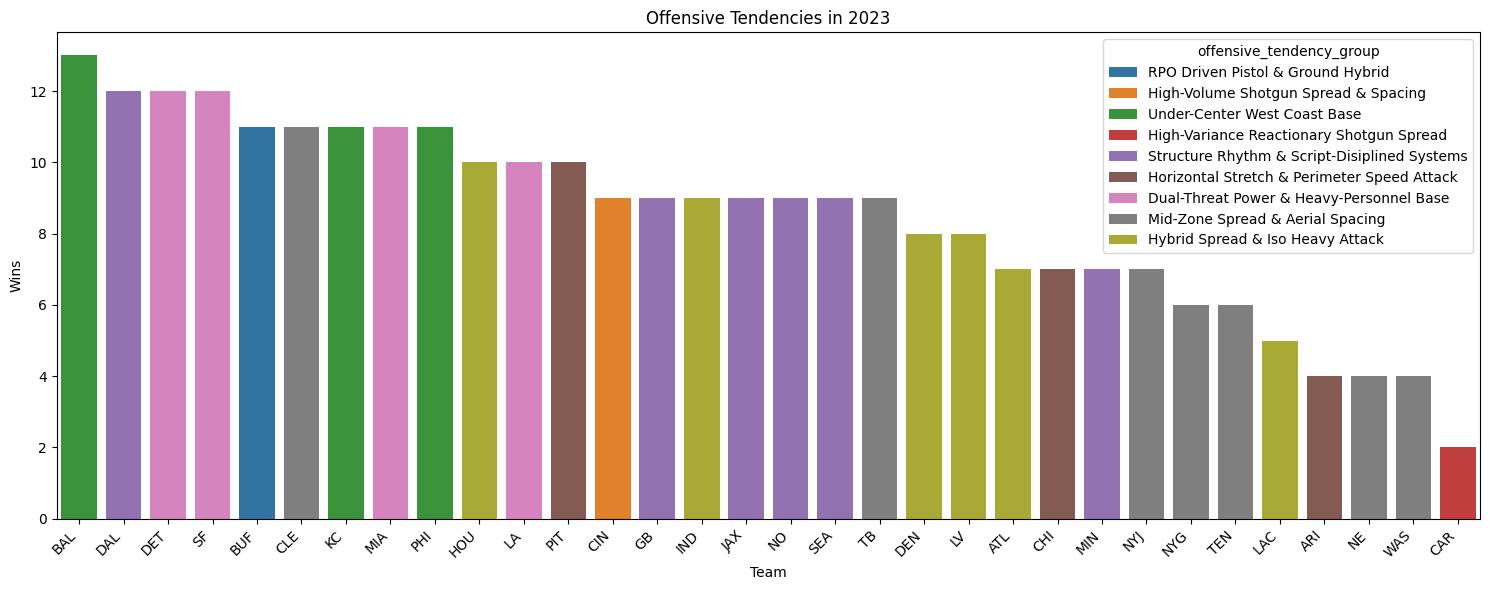

In [33]:
plt.figure(figsize = (15, 6))

sns.barplot(data = standings_2023, x = "team", y = "W", hue = "offensive_tendency_group",
            hue_order = style_order, palette = "tab10")

plt.title("Offensive Tendencies in 2023")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation = 45, ha = "right")

plt.tight_layout()
plt.show()

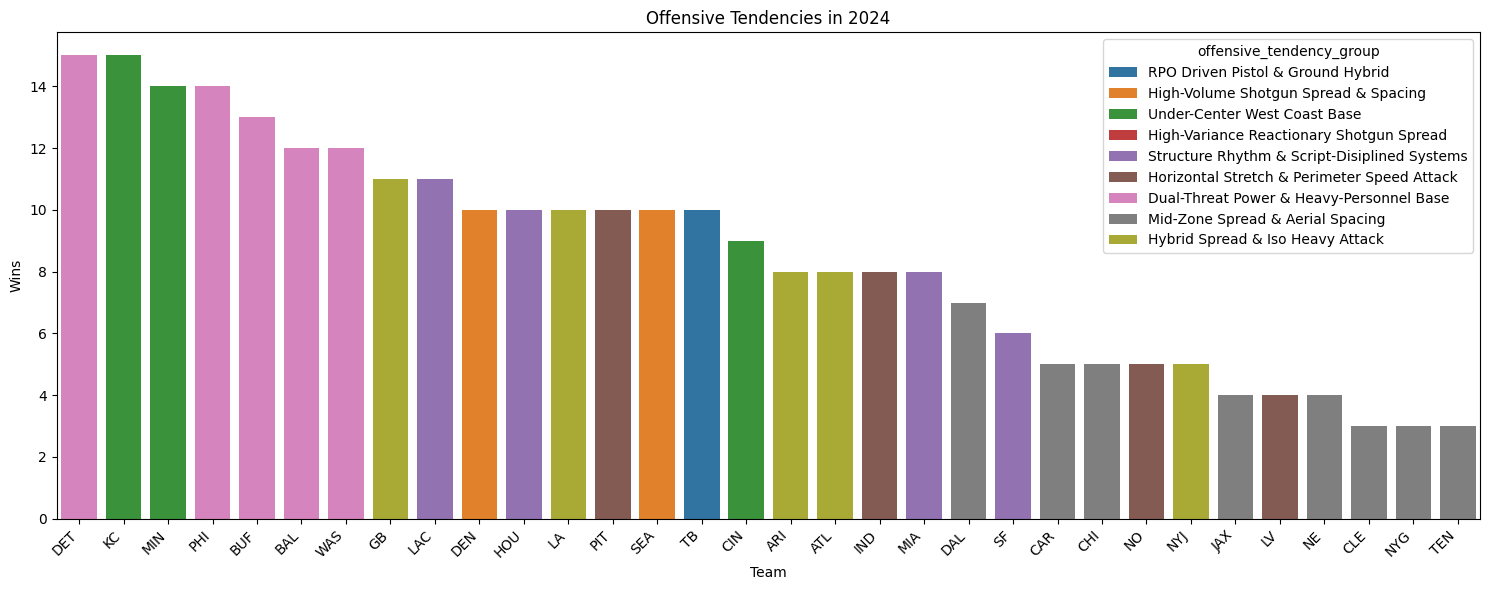

In [34]:
plt.figure(figsize = (15, 6))

sns.barplot(data = standings_2024, x = "team", y = "W", hue = "offensive_tendency_group",
            hue_order = style_order, palette = "tab10")

plt.title("Offensive Tendencies in 2024")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation = 45, ha = "right")

plt.tight_layout()
plt.show()

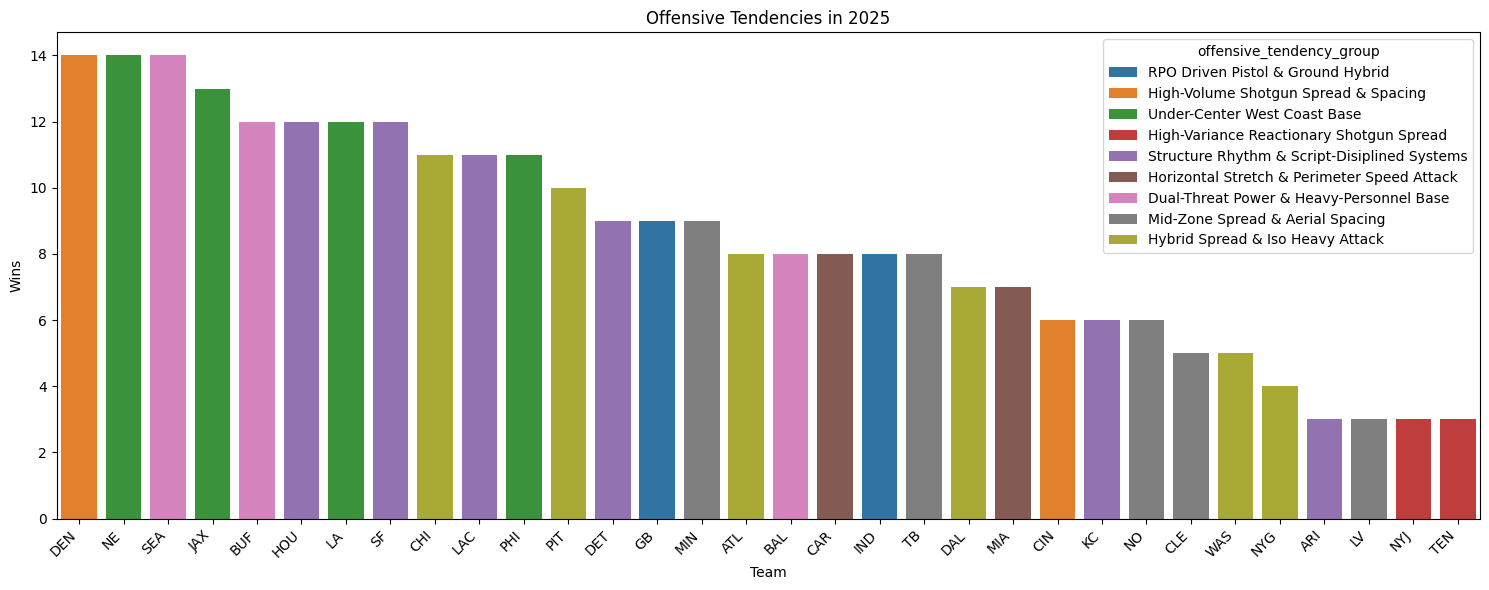

In [36]:
plt.figure(figsize = (15, 6))

sns.barplot(data = standings_2025, x = "team", y = "W", hue = "offensive_tendency_group",
            hue_order = style_order, palette = "tab10")

plt.title("Offensive Tendencies in 2025")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation = 45, ha = "right")

plt.tight_layout()
plt.show()

# Offensive Philosophies and their Win Rates Over Time

The following line chart answers the question, "Do certain offensive philosophies tend to win more than others?". And the answer is a resounding "Yes!". There are clear strategies which sit above the rest, and clear strategies which sit below the rest.

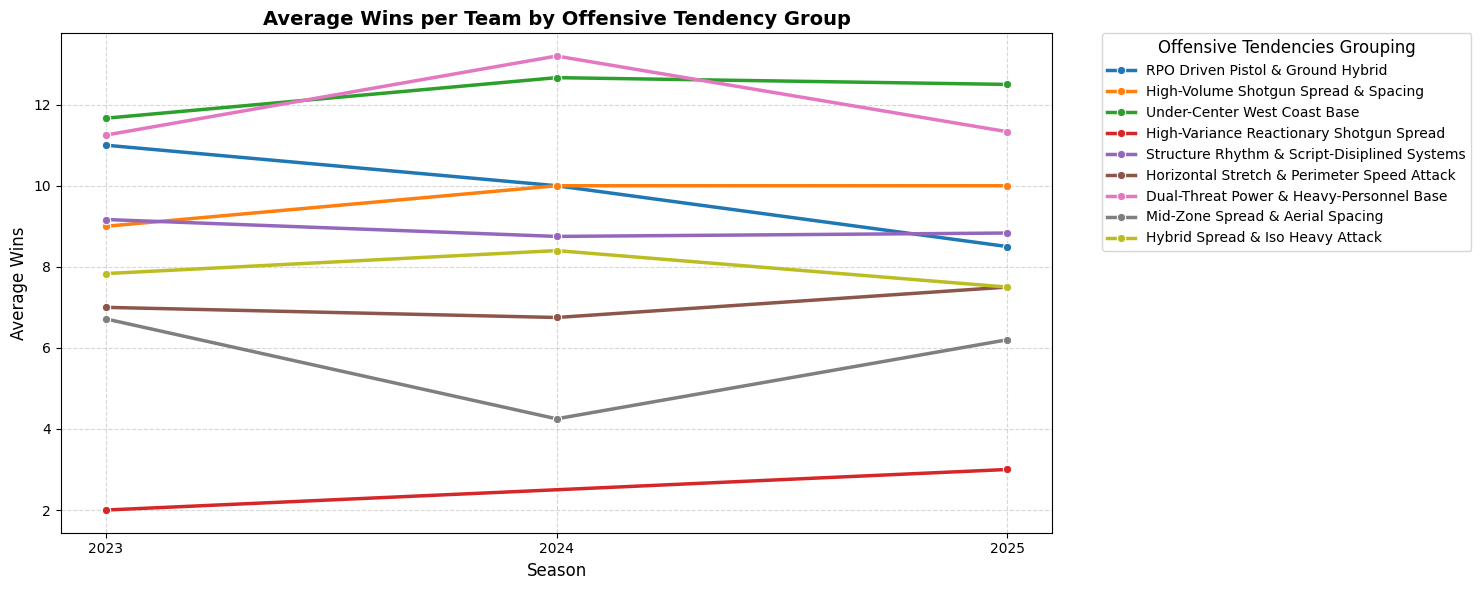

In [37]:
average_wins_df = standings.groupby(["season", "offensive_tendency_group"])["W"].mean().reset_index()

plt.figure(figsize = (15, 6))

sns.lineplot(
    data = average_wins_df,
    x = "season",
    y = "W",
    hue = "offensive_tendency_group",
    marker = "o",
    linewidth = 2.5,
    palette = "tab10",
    hue_order = style_order
)

plt.legend(
    title = "Offensive Tendencies Grouping",
    title_fontsize = "12",
    bbox_to_anchor = (1.05, 1),
    loc = "upper left",
    borderaxespad = 0
)

plt.title("Average Wins per Team by Offensive Tendency Group", fontsize = 14, fontweight = "bold")
plt.xlabel("Season", fontsize = 12)
plt.ylabel("Average Wins", fontsize = 12)

plt.xticks(average_wins_df["season"].unique().astype(int))

plt.grid(True, linestyle = "--", alpha = 0.5)
plt.tight_layout()
plt.show()

# Within-Team Offensive Philosophy Evolution

The next two bar charts are different versions of eachother, one revealing team win totals and whether changes in wins year-over-year coincided with changes in offensive play-calling, and the other revealing which strategies were most prevalent over the teams we've seen the most success from over this 3 season span.

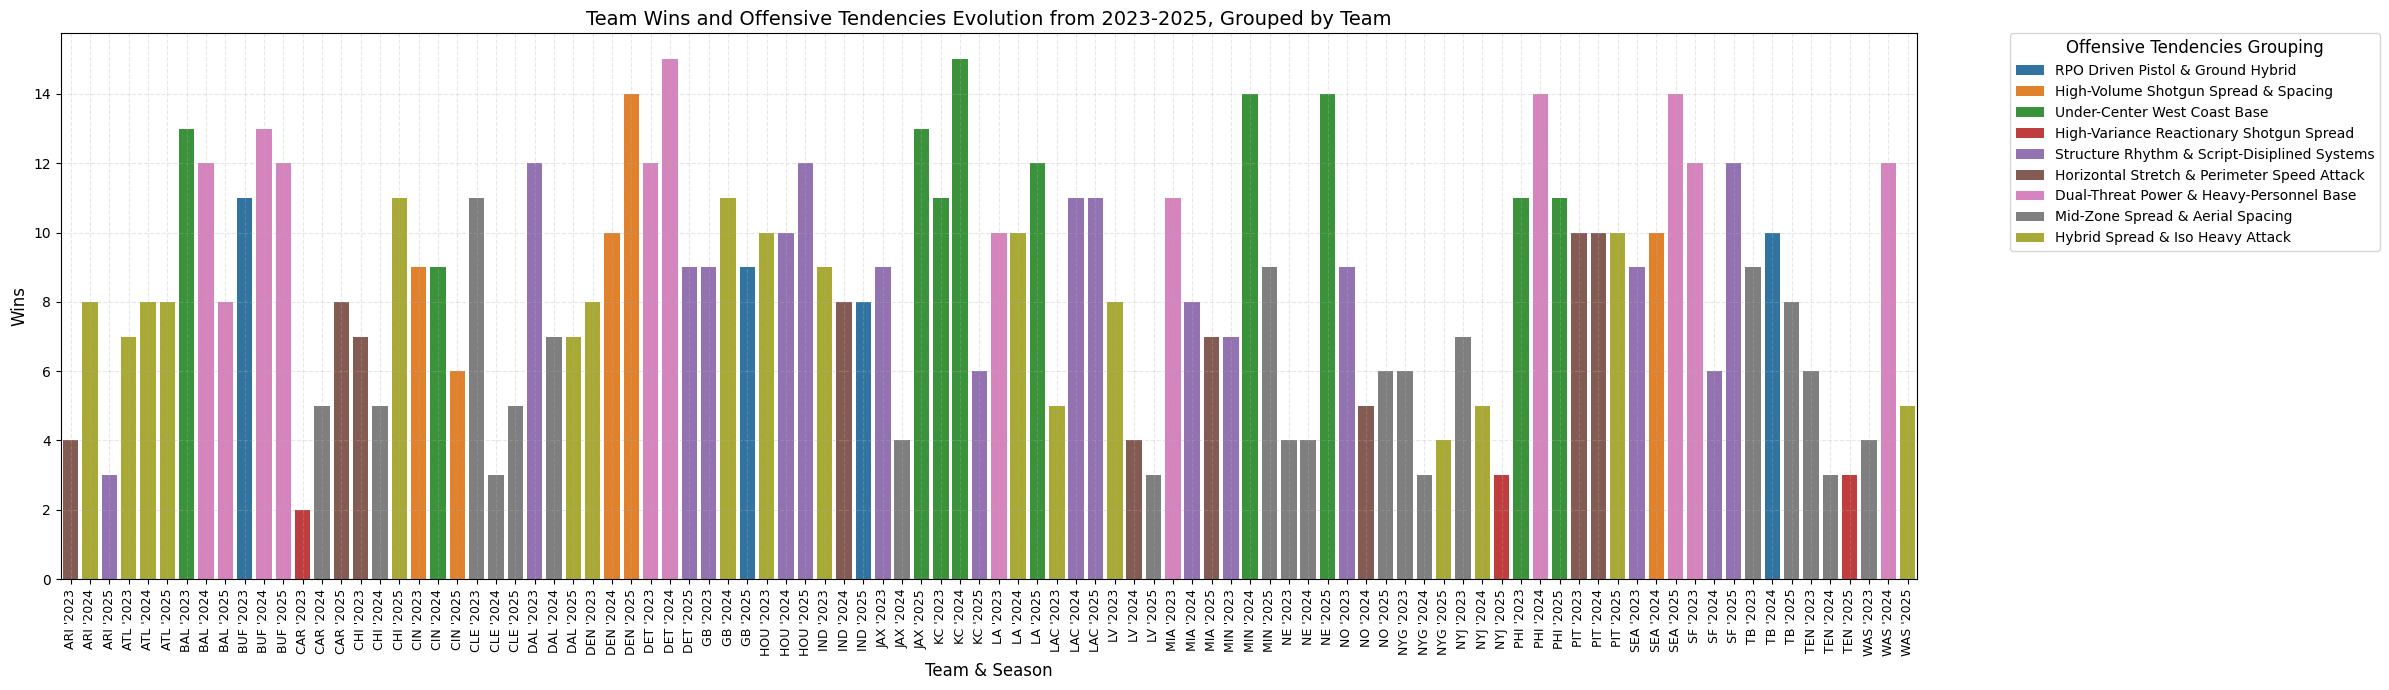

In [38]:
standings_timeline = standings.sort_values(["team", "season"]).copy()

standings_timeline["team_season"] = (
    standings_timeline["team"] + " '" + standings_timeline["season"].astype(str)
)

plt.figure(figsize = (24, 7))

sns.barplot(
    data = standings_timeline,
    x = "team_season",
    y = "W",
    hue = "offensive_tendency_group",
    hue_order = style_order,
    palette = "tab10"
)

plt.title("Team Wins and Offensive Tendencies Evolution from 2023-2025, Grouped by Team", fontsize = 14)
plt.xlabel("Team & Season", fontsize = 12)
plt.ylabel("Wins", fontsize = 12)

plt.xticks(rotation = 90, fontsize = 9)
plt.grid(True, linestyle = "--", alpha = 0.3)

plt.legend(
    title = "Offensive Tendencies Grouping",
    title_fontsize = "12",
    bbox_to_anchor = (1.05, 1),
    loc = "upper left",
    borderaxespad = 0
)

plt.tight_layout()
plt.show()

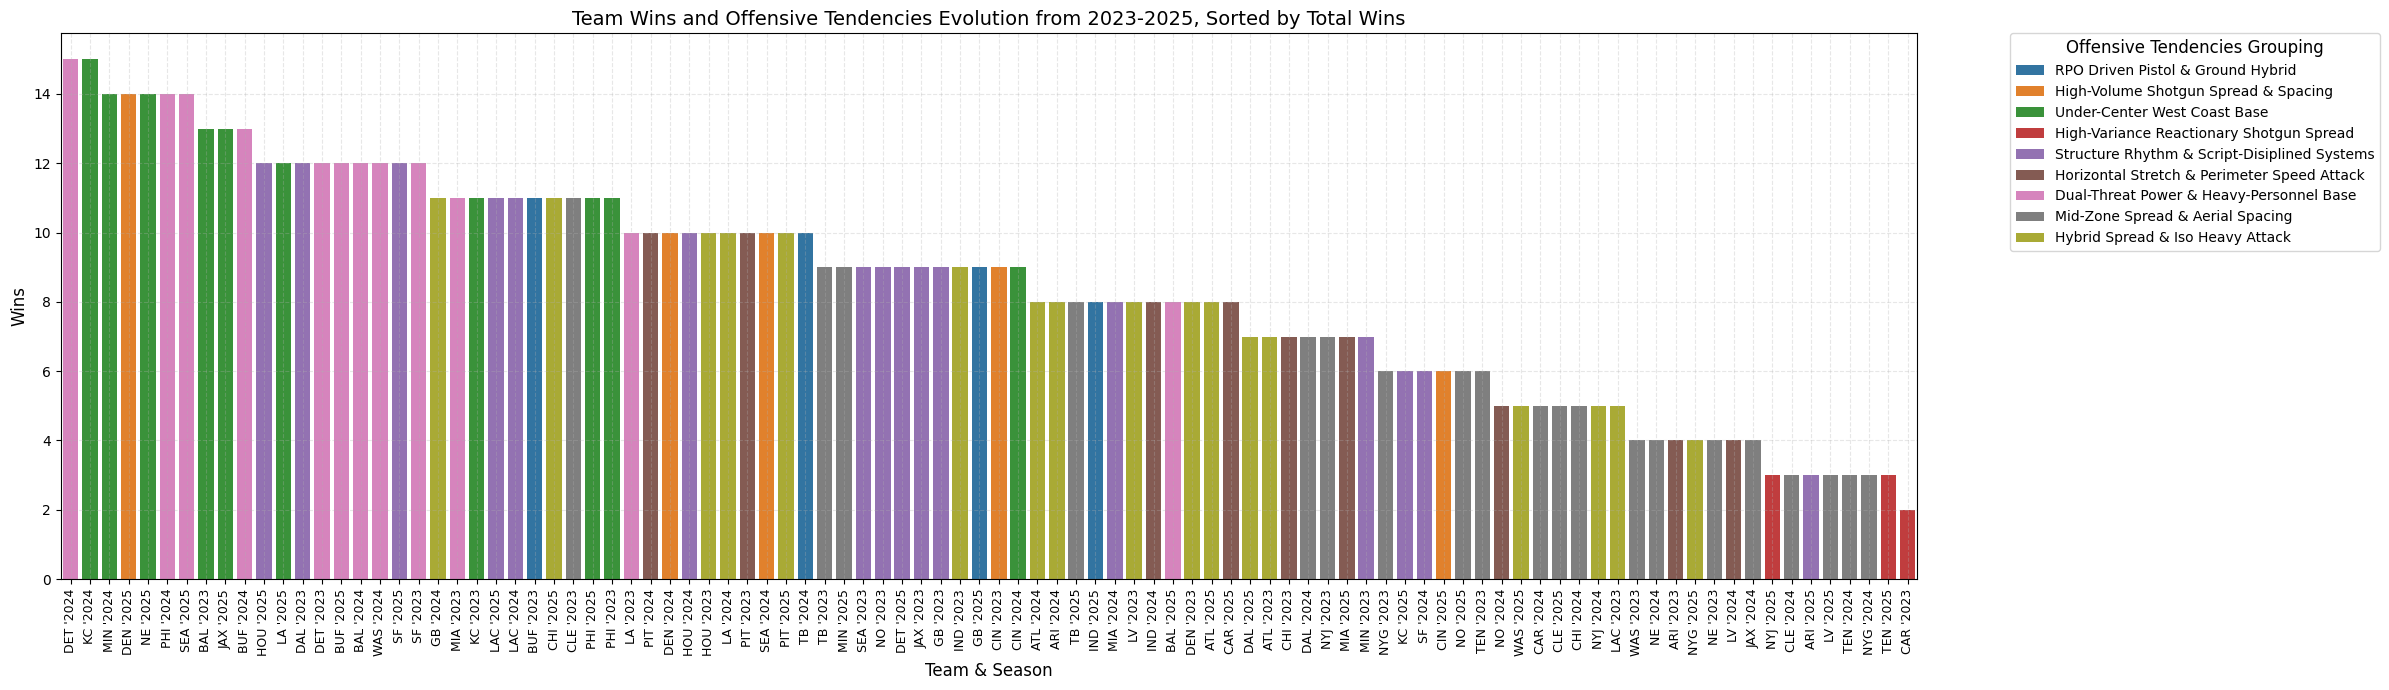

In [39]:
standings_timeline_sorted = standings_timeline.sort_values("W", ascending = False).copy()

plt.figure(figsize = (24, 7))

sns.barplot(
    data = standings_timeline_sorted,
    x = "team_season",
    y = "W",
    hue = "offensive_tendency_group",
    hue_order = style_order,
    palette = "tab10"
)

plt.title("Team Wins and Offensive Tendencies Evolution from 2023-2025, Sorted by Total Wins", fontsize = 14)
plt.xlabel("Team & Season", fontsize = 12)
plt.ylabel("Wins", fontsize = 12)

plt.xticks(rotation = 90, fontsize = 9)
plt.grid(True, linestyle = "--", alpha = 0.3)

plt.legend(
    title = "Offensive Tendencies Grouping",
    title_fontsize = "12",
    bbox_to_anchor = (1.05, 1),
    loc = "upper left",
    borderaxespad = 0
)

plt.tight_layout()
plt.show()